# Creating the CNN
We will be using a Convolutional Neural Network to predict if audio has been deepfaked.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load .npz file containing spectrograms
data = np.load('processed_data.npz')
X_train, y_train = data['x_train'], data['y_train']
X_val, y_val = data['x_val'], data['y_val']
X_test, y_test = data['x_test'], data['y_test']

print(f"Imported Data. Training on {X_train.shape[0]} samples of {X_train.shape[1:]}")

Imported Data. Training on 13956 samples of (128, 44, 2)


# Create the Model



In [2]:
from tensorflow.keras import layers, models

def build_robust_cnn(input_shape):
    model = models.Sequential()

    # --- Block 1 ---
    # Removed activation='relu' from here since it's applied after BatchNormalization
    model.add(layers.Conv2D(32, (3, 3), input_shape=input_shape)) 
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    # --- Block 2 ---
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.SpatialDropout2D(0.3))

    # --- Flatten & Dense ---
    model.add(layers.Flatten())
    model.add(layers.Dense(64)) # Increased from 16 to 64
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4)) # Lowered dropout rate
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

# Use your new shape (128, 44, 2)
model = build_robust_cnn((128, 44, 2))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Slightly lower LR
              loss='binary_crossentropy',
              metrics=['accuracy'])

C:\Users\Brandon\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,          # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 122s 538ms/step - accuracy: 0.8410 - loss: 0.3616 - val_accuracy: 0.5001 - val_loss: 2.3482
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 542ms/step - accuracy: 0.9397 - loss: 0.1747 - val_accuracy: 0.5001 - val_loss: 1.8894
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 135s 512ms/step - accuracy: 0.9675 - loss: 0.1175 - val_accuracy: 0.7463 - val_loss: 0.4604
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 148s 538ms/step - accuracy: 0.9796 - loss: 0.0886 - val_accuracy: 0.9822 - val_loss: 0.0730
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 541ms/step - accuracy: 0.9855 - loss: 0.0685 - val_accuracy: 0.9922 - val_loss: 0.0508
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 134s 506ms/step - accuracy: 0.9901 - loss: 0.0533 - val_accuracy: 0.9935 - val_loss: 0.0380
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 117s 535ms/step - accuracy: 0.9914 - loss: 0.0463 - val_accuracy: 0.9900 - val_loss: 0.0424
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 143s 541ms/step - accuracy: 0.9893 -

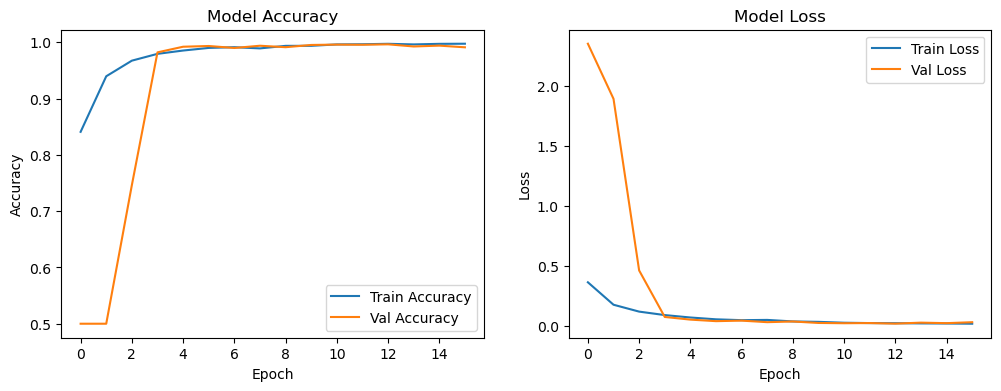

In [4]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Testing with the Test Data

In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

63/63 - 3s - 47ms/step - accuracy: 0.5725 - loss: 1.3374

Final Test Accuracy: 57.25%


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


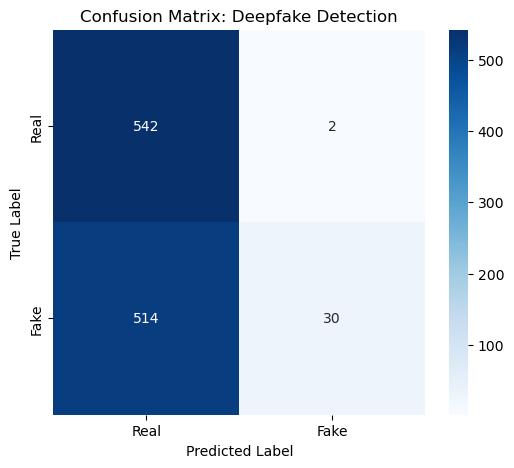

              precision    recall  f1-score   support

        Real       0.51      1.00      0.68       544
        Fake       0.94      0.06      0.10       544

    accuracy                           0.53      1088
   macro avg       0.73      0.53      0.39      1088
weighted avg       0.73      0.53      0.39      1088



In [84]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the model's predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to hard labels (0 or 1)
# Since we used a sigmoid output, anything > 0.5 is "Fake" (1)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Create the Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it beautifully
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Deepfake Detection')
plt.show()

# 5. Print the full report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))